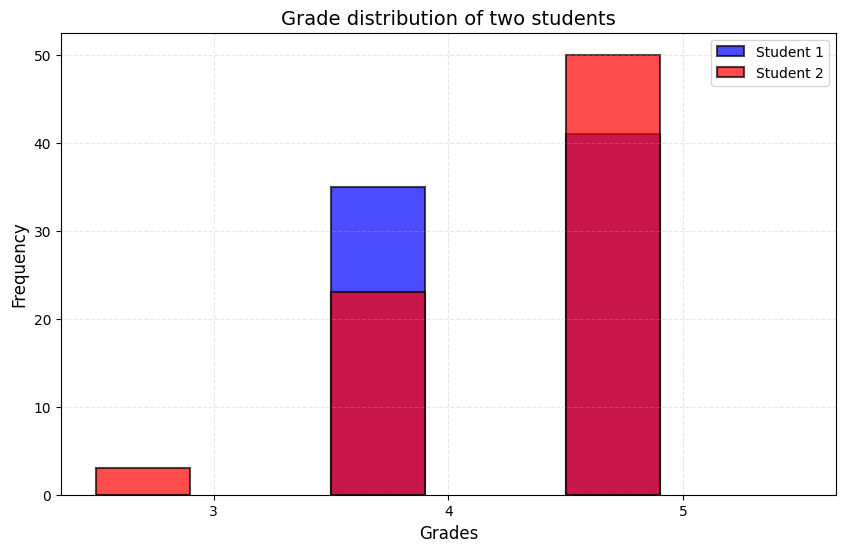


Описательные статистики:
Student 1: n=76, mean=4.54, median=5, std=0.50
Student 2: n=76, mean=4.62, median=5, std=0.56

1. Критерий Колмогорова-Смирнова:
   Статистика D = 0.1184
   p-value = 0.6643
   Вывод: Принимаем H0

2. Критерий омега-квадрат (Андерсона-Дарлинга):
   Статистика = 0.9257
   Критические значения: [0.325 1.226 1.961 2.718 3.752 4.592 6.546]
   Вывод: Принимаем H0

3. Критерий Манна-Уитни:
   Статистика U = 2598.5
   p-value = 0.2126
   Вывод: Принимаем H0

4. Критерий хи-квадрат:
   Вариант 1 (3 интервала): χ² = 6.3729, df = 2, p-value = 0.0413
   Вывод: Отвергаем H0
   Вариант 2 (2 интервала): χ² = 1.7525, df = 1, p-value = 0.1856
   Вывод: Принимаем H0

5. Критерий знаков (для связанных выборок):
   Положительных: 10, Отрицательных: 17, Равенств: 49
   p-value = 0.2478
   Вывод: Принимаем H0

6. Критерий Уилкоксона:
   Статистика = 148.5
   p-value = 0.2733
   Вывод: Принимаем H0


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Данные студентов
student1 = [5,5,5,5,5,5,5,5,4,4,4,4,5,4,5,5,5,5,5,5,4,4,5,4,5,4,5,4,5,5,
            4,5,4,4,4,4,5,4,4,5,5,5,4,4,5,5,4,5,5,5,4,4,5,4,5,4,5,4,5,4,
            5,5,5,4,5,5,5,4,4,4,4,4,4,4,4,5]
student2 = [5,5,5,4,5,5,5,5,4,5,4,5,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
            5,5,5,5,4,5,5,5,5,5,5,5,4,3,4,5,4,5,4,5,5,4,5,5,4,4,5,4,4,4,
            5,5,5,5,4,3,4,4,5,4,4,4,4,3,4,5]

# Гистограмма
plt.figure(figsize=(10, 6))
bins = [2.5, 3.5, 4.5, 5.5]
plt.hist(student1, bins=bins, alpha=0.7, label='Student 1', color='blue', edgecolor='black', linewidth=1.5, width=0.4)
plt.hist(student2, bins=bins, alpha=0.7, label='Student 2', color='red', edgecolor='black', linewidth=1.5, width=0.4)
plt.xlabel('Grades', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Grade distribution of two students', fontsize=14)
plt.legend(loc='upper right')
plt.xticks([3, 4, 5])
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

# Описательные статистики
print("\nОписательные статистики:")
print(f"Student 1: n={len(student1)}, mean={np.mean(student1):.2f}, median={np.median(student1):.0f}, std={np.std(student1):.2f}")
print(f"Student 2: n={len(student2)}, mean={np.mean(student2):.2f}, median={np.median(student2):.0f}, std={np.std(student2):.2f}")

# Критерий Колмогорова-Смирнова
ks_stat, ks_p = stats.ks_2samp(student1, student2)
print(f"\n1. Критерий Колмогорова-Смирнова:")
print(f"   Статистика D = {ks_stat:.4f}")
print(f"   p-value = {ks_p:.4f}")
print(f"   Вывод: {'Отвергаем H0' if ks_p < 0.05 else 'Принимаем H0'}")

# Критерий омега-квадрат (Андерсона-Дарлинга)
ad_result = stats.anderson_ksamp([student1, student2])
print(f"\n2. Критерий омега-квадрат (Андерсона-Дарлинга):")
print(f"   Статистика = {ad_result.statistic:.4f}")
print(f"   Критические значения: {ad_result.critical_values}")
print(f"   Вывод: {'Отвергаем H0' if ad_result.statistic > ad_result.critical_values[2] else 'Принимаем H0'}")

# Критерий Манна-Уитни
mu_stat, mu_p = stats.mannwhitneyu(student1, student2, alternative='two-sided')
print(f"\n3. Критерий Манна-Уитни:")
print(f"   Статистика U = {mu_stat:.1f}")
print(f"   p-value = {mu_p:.4f}")
print(f"   Вывод: {'Отвергаем H0' if mu_p < 0.05 else 'Принимаем H0'}")

# Критерий хи-квадрат
print(f"\n4. Критерий хи-квадрат:")

# Вариант 1: 3 интервала
grades = [3, 4, 5]
cont_table = []
for grade in grades:
    row = [sum(1 for x in student1 if x == grade), sum(1 for x in student2 if x == grade)]
    cont_table.append(row)
obs = np.array(cont_table).T
chi2_3, p_3, dof_3, expected_3 = stats.chi2_contingency(obs)
print(f"   Вариант 1 (3 интервала): χ² = {chi2_3:.4f}, df = {dof_3}, p-value = {p_3:.4f}")
print(f"   Вывод: {'Отвергаем H0' if p_3 < 0.05 else 'Принимаем H0'}")

# Вариант 2: 2 интервала
low1 = sum(1 for x in student1 if x <= 4)
high1 = sum(1 for x in student1 if x == 5)
low2 = sum(1 for x in student2 if x <= 4)
high2 = sum(1 for x in student2 if x == 5)
obs_bin = np.array([[low1, high1], [low2, high2]])
chi2_2, p_2, dof_2, exp_2 = stats.chi2_contingency(obs_bin)
print(f"   Вариант 2 (2 интервала): χ² = {chi2_2:.4f}, df = {dof_2}, p-value = {p_2:.4f}")
print(f"   Вывод: {'Отвергаем H0' if p_2 < 0.05 else 'Принимаем H0'}")

# Критерий знаков
print(f"\n5. Критерий знаков (для связанных выборок):")
if len(student1) == len(student2):
    diff = []
    for i in range(len(student1)):
        if student1[i] > student2[i]:
            diff.append('+')
        elif student1[i] < student2[i]:
            diff.append('-')
        else:
            diff.append('=')
    n_plus = diff.count('+')
    n_minus = diff.count('-')
    n_equal = diff.count('=')
    n_total = n_plus + n_minus
    p_value_sign = stats.binomtest(n_plus, n_total, p=0.5, alternative='two-sided').pvalue
    print(f"   Положительных: {n_plus}, Отрицательных: {n_minus}, Равенств: {n_equal}")
    print(f"   p-value = {p_value_sign:.4f}")
    print(f"   Вывод: {'Отвергаем H0' if p_value_sign < 0.05 else 'Принимаем H0'}")

    # Критерий Уилкоксона
    stat, p_value_wilcox = stats.wilcoxon(student1, student2, alternative='two-sided')
    print(f"\n6. Критерий Уилкоксона:")
    print(f"   Статистика = {stat:.1f}")
    print(f"   p-value = {p_value_wilcox:.4f}")
    print(f"   Вывод: {'Отвергаем H0' if p_value_wilcox < 0.05 else 'Принимаем H0'}")